# Compare One-Shot And Sequential Baselines

This notebook loads the selected one-shot full artifact and one sequential sampled run, aligns them on the exact same `case_id`s, and saves paired comparison outputs under `artifacts/comparisons/`.


In [33]:
from __future__ import annotations

import ast
import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / "scripts" / "download_ddxplus.py").exists()
    ),
    Path.cwd(),
)
ONE_SHOT_SELECTED_PATH = ROOT / "artifacts" / "one_shot" / "selected_model.json"
SEQUENTIAL_RUN_NAME = None  # set this explicitly to compare a specific sequential run
COMPARISON_ROOT = ROOT / "artifacts" / "comparisons"
COMPARISON_ROOT.mkdir(parents=True, exist_ok=True)


## Artifact Loading Helpers

The one-shot side is expected to come from notebook 01 after a full run. The sequential side is expected to come from notebook 02 after a sampled API-backed run.


In [34]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    records = []
    if not path.exists():
        return records
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return records


def parse_list_like(value: Any) -> list[str]:
    if isinstance(value, list):
        return [str(item) for item in value]
    if value is None:
        return []
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            parsed = ast.literal_eval(stripped)
            if isinstance(parsed, list):
                return [str(item) for item in parsed]
        except Exception:
            pass
        parts = [item.strip() for item in stripped.split("|") if item.strip()]
        return [item.split(":")[0] for item in parts]
    return []


def discover_selected_one_shot_dir() -> Path:
    if ONE_SHOT_SELECTED_PATH.exists():
        payload = load_json(ONE_SHOT_SELECTED_PATH)
        return Path(payload["selected_artifact_dir"])
    candidates = sorted(
        [
            path for path in (ROOT / "artifacts" / "one_shot").glob("*_full")
            if (path / "predictions.csv").exists()
        ]
    )
    if not candidates:
        raise FileNotFoundError("No one-shot full artifacts found. Run notebook 01 first.")
    return max(candidates, key=lambda path: path.stat().st_mtime)


def discover_sequential_dir() -> Path:
    if SEQUENTIAL_RUN_NAME:
        path = ROOT / "artifacts" / "sequential_single_agent" / SEQUENTIAL_RUN_NAME
        if not (path / "predictions.csv").exists():
            raise FileNotFoundError(f"Sequential run not found: {path}")
        return path
    candidates = [
        path for path in (ROOT / "artifacts" / "sequential_single_agent").glob("*")
        if (path / "predictions.csv").exists()
    ]
    if not candidates:
        raise FileNotFoundError("No sequential artifacts found. Run notebook 02 first.")
    return max(candidates, key=lambda path: path.stat().st_mtime)


def top_k_accuracy_from_lists(true_labels: list[str], ranked_lists: list[list[str]], k: int) -> float:
    hits = [int(truth in ranked[:k]) for truth, ranked in zip(true_labels, ranked_lists)]
    return float(np.mean(hits)) if hits else 0.0


def macro_f1_from_names(true_labels: list[str], predicted_labels: list[str], label_names: list[str]) -> float:
    label_to_index = {label: idx for idx, label in enumerate(label_names)}
    gold = np.array([label_to_index[item] for item in true_labels], dtype=np.int64)
    pred = np.array([label_to_index[item] for item in predicted_labels], dtype=np.int64)
    scores = []
    for class_idx in range(len(label_names)):
        tp = np.sum((gold == class_idx) & (pred == class_idx))
        fp = np.sum((gold != class_idx) & (pred == class_idx))
        fn = np.sum((gold == class_idx) & (pred != class_idx))
        precision = tp / max(1, tp + fp)
        recall = tp / max(1, tp + fn)
        scores.append(0.0 if precision + recall == 0 else (2 * precision * recall) / (precision + recall))
    return float(np.mean(scores))


## Load Artifacts And Align On Shared `case_id`s

The sequential benchmark defines the paired sample. The one-shot predictions are filtered down to the same case list so the comparison is apples-to-apples.


In [35]:
one_shot_dir = discover_selected_one_shot_dir()
sequential_dir = discover_sequential_dir()

one_shot_predictions = pd.read_csv(one_shot_dir / "predictions.csv")
sequential_predictions = pd.read_csv(sequential_dir / "predictions.csv")
one_shot_metrics = load_json(one_shot_dir / "metrics.json")
sequential_metrics = load_json(sequential_dir / "metrics.json")

shared_case_ids = sorted(set(sequential_predictions["case_id"]) & set(one_shot_predictions["case_id"]))
if len(shared_case_ids) != len(sequential_predictions):
    missing = sorted(set(sequential_predictions["case_id"]) - set(one_shot_predictions["case_id"]))
    raise ValueError(
        "The one-shot artifact does not cover every sequential case_id. "
        f"Missing examples: {missing[:5]}"
    )

one_shot_paired = (
    one_shot_predictions[one_shot_predictions["case_id"].isin(shared_case_ids)]
    .copy()
    .sort_values("case_id")
    .reset_index(drop=True)
)
sequential_paired = (
    sequential_predictions[sequential_predictions["case_id"].isin(shared_case_ids)]
    .copy()
    .sort_values("case_id")
    .reset_index(drop=True)
)

traces = {record["case_id"]: record for record in read_jsonl(sequential_dir / "traces.jsonl")}
label_names = sorted(one_shot_paired["true_pathology"].unique().tolist())

paired = pd.DataFrame(
    {
        "case_id": one_shot_paired["case_id"],
        "true_pathology": one_shot_paired["true_pathology"],
        "one_shot_pred": one_shot_paired["pred_pathology"],
        "one_shot_top5": one_shot_paired["top5_predictions"].map(parse_list_like),
        "sequential_pred": sequential_paired["predicted_pathology"],
        "sequential_ranked": sequential_paired["ranked_differential"].map(parse_list_like),
        "sequential_num_requests": sequential_paired["num_requests"],
        "sequential_stop_reason": sequential_paired["stop_reason"],
        "sequential_api_calls": sequential_paired["api_calls"],
        "sequential_input_tokens": sequential_paired["input_tokens"],
        "sequential_output_tokens": sequential_paired["output_tokens"],
        "sequential_estimated_cost": sequential_paired["estimated_cost"],
    }
)
paired["one_shot_correct"] = paired["one_shot_pred"] == paired["true_pathology"]
paired["sequential_correct"] = paired["sequential_pred"] == paired["true_pathology"]

print("One-shot dir   :", one_shot_dir)
print("Sequential dir :", sequential_dir)
print("Paired cases   :", len(paired))
display(paired.head())


One-shot dir   : /Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_pathology_full
Sequential dir : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent/single_agent_live_test_1perclass_max3_decoded_gated_v3_gpt54mini
Paired cases   : 49


,case_id,true_pathology,one_shot_pred,one_shot_top5,sequential_pred,sequential_ranked,sequential_num_requests,sequential_stop_reason,sequential_api_calls,sequential_input_tokens,sequential_output_tokens,sequential_estimated_cost,one_shot_correct,sequential_correct
0,test:100142,Atrial fibrillation,Stable angina,"[Stable angina, Unstable angina, Acute pulmona...",Stable angina,"[Stable angina, Unstable angina, Possible NSTE...",2,agent_stop,3,12858,293,NaN,False,False
1,test:102152,Panic attack,Anemia,"[Anemia, PSVT, Panic attack, Anaphylaxis, Scom...",Panic attack,"[Panic attack, Anemia, Pulmonary embolism, PSV...",2,agent_stop,3,12928,292,NaN,False,True
2,test:102369,Inguinal hernia,Inguinal hernia,"[Inguinal hernia, Whooping cough, Spontaneous ...",Whooping cough,"[Whooping cough, Bronchitis, URTI, Bronchospas...",2,agent_stop,3,12822,335,NaN,True,False
3,test:103777,Myocarditis,Pericarditis,"[Pericarditis, GERD, Acute pulmonary edema, My...",Pericarditis,"[Pericarditis, GERD, Pneumonia, Pulmonary embo...",1,agent_stop,2,8560,195,NaN,False,False
4,test:104410,Epiglottitis,Acute laryngitis,"[Acute laryngitis, Epiglottitis, Acute rhinosi...",Epiglottitis,"[Epiglottitis, Croup, Acute laryngitis, Viral ...",1,agent_stop,2,8566,220,NaN,False,True


## Paired Metrics, Win/Loss Table, And Saved Outputs

This cell computes the paired comparison metrics and writes:

- `summary_metrics.json`
- `paired_case_results.csv`
- `pathology_delta.csv`
- `qualitative_trace_examples.json`


,accuracy,top3_accuracy,top5_accuracy,macro_f1
one_shot,0.387755,0.653061,0.775510,0.329446
sequential,0.244898,0.367347,0.489796,0.159524


,both_correct,sequential_only_correct,one_shot_only_correct,both_wrong
0,7,5,12,25


,pathology,count,one_shot_accuracy,sequential_accuracy,delta_accuracy
24,Influenza,1,0.0,1.0,1.0
36,Pulmonary embolism,1,0.0,1.0,1.0
32,Panic attack,1,0.0,1.0,1.0
13,Bronchitis,1,0.0,1.0,1.0
20,Epiglottitis,1,0.0,1.0,1.0
28,Myasthenia gravis,1,0.0,0.0,0.0
43,Stable angina,1,1.0,1.0,0.0
23,HIV (initial infection),1,0.0,0.0,0.0
1,Acute dystonic reactions,1,1.0,1.0,0.0
42,Spontaneous rib fracture,1,1.0,1.0,0.0


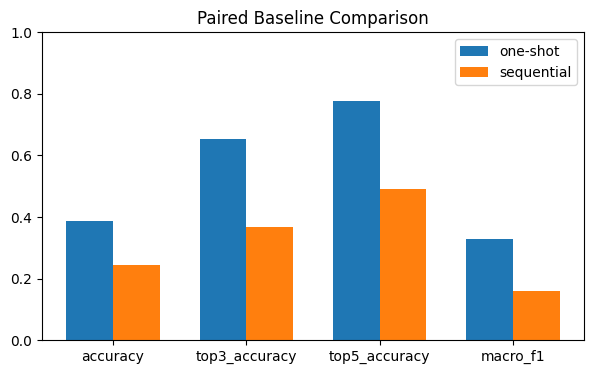

{'run_pair_name': 'basd_pathology_full__vs__single_agent_live_test_1perclass_max3_decoded_gated_v3_gpt54mini',
 'num_paired_cases': 49,
 'one_shot': {'accuracy': 0.3877551020408163,
  'top3_accuracy': 0.6530612244897959,
  'top5_accuracy': 0.7755102040816326,
  'macro_f1': 0.3294460641399417},
 'sequential': {'accuracy': 0.24489795918367346,
  'top3_accuracy': 0.3673469387755102,
  'top5_accuracy': 0.4897959183673469,
  'macro_f1': 0.1595238095238095},
 'win_loss': {'both_correct': 7,
  'sequential_only_correct': 5,
  'one_shot_only_correct': 12,
  'both_wrong': 25},
 'mean_requests': 1.9183673469387754,
 'stop_rate_before_cap': 0.6938775510204082,
 'turn_distribution': {0: 2, 1: 15, 2: 17, 3: 15},
 'total_input_tokens': 563729,
 'total_output_tokens': 13966,
 'total_estimated_cost': None,
 'source_artifacts': {'one_shot_dir': '/Users/bilalawan/claw/assignments/baseline_model/artifacts/one_shot/basd_pathology_full',
  'sequential_dir': '/Users/bilalawan/claw/assignments/baseline_model/

In [36]:
one_shot_metrics_paired = {
    "accuracy": float(np.mean(paired["one_shot_correct"])),
    "top3_accuracy": top_k_accuracy_from_lists(
        paired["true_pathology"].tolist(),
        paired["one_shot_top5"].tolist(),
        3,
    ),
    "top5_accuracy": top_k_accuracy_from_lists(
        paired["true_pathology"].tolist(),
        paired["one_shot_top5"].tolist(),
        5,
    ),
    "macro_f1": macro_f1_from_names(
        paired["true_pathology"].tolist(),
        paired["one_shot_pred"].tolist(),
        label_names,
    ),
}
sequential_metrics_paired = {
    "accuracy": float(np.mean(paired["sequential_correct"])),
    "top3_accuracy": top_k_accuracy_from_lists(
        paired["true_pathology"].tolist(),
        paired["sequential_ranked"].tolist(),
        3,
    ),
    "top5_accuracy": top_k_accuracy_from_lists(
        paired["true_pathology"].tolist(),
        paired["sequential_ranked"].tolist(),
        5,
    ),
    "macro_f1": macro_f1_from_names(
        paired["true_pathology"].tolist(),
        paired["sequential_pred"].tolist(),
        label_names,
    ),
}

win_loss = {
    "both_correct": int(np.sum(paired["one_shot_correct"] & paired["sequential_correct"])),
    "sequential_only_correct": int(np.sum(~paired["one_shot_correct"] & paired["sequential_correct"])),
    "one_shot_only_correct": int(np.sum(paired["one_shot_correct"] & ~paired["sequential_correct"])),
    "both_wrong": int(np.sum(~paired["one_shot_correct"] & ~paired["sequential_correct"])),
}

pathology_rows = []
for pathology, group in paired.groupby("true_pathology"):
    one_shot_acc = float(np.mean(group["one_shot_correct"]))
    sequential_acc = float(np.mean(group["sequential_correct"]))
    pathology_rows.append(
        {
            "pathology": pathology,
            "count": int(len(group)),
            "one_shot_accuracy": one_shot_acc,
            "sequential_accuracy": sequential_acc,
            "delta_accuracy": sequential_acc - one_shot_acc,
        }
    )
pathology_delta = pd.DataFrame(pathology_rows).sort_values("delta_accuracy", ascending=False)

seq_trace_examples = []
for case_id in paired.loc[(~paired["one_shot_correct"]) & (paired["sequential_correct"]), "case_id"].head(5):
    if case_id in traces:
        seq_trace_examples.append(traces[case_id])
for case_id in paired.loc[(paired["one_shot_correct"]) & (~paired["sequential_correct"]), "case_id"].head(5):
    if case_id in traces:
        seq_trace_examples.append(traces[case_id])

run_pair_name = f"{one_shot_dir.name}__vs__{sequential_dir.name}"
output_dir = COMPARISON_ROOT / run_pair_name
output_dir.mkdir(parents=True, exist_ok=True)

summary_metrics = {
    "run_pair_name": run_pair_name,
    "num_paired_cases": int(len(paired)),
    "one_shot": one_shot_metrics_paired,
    "sequential": sequential_metrics_paired,
    "win_loss": win_loss,
    "mean_requests": float(paired["sequential_num_requests"].mean()),
    "stop_rate_before_cap": float(
        np.mean(
            (paired["sequential_stop_reason"] == "agent_stop")
            & (paired["sequential_num_requests"] < paired["sequential_num_requests"].max())
        )
    ),
    "turn_distribution": paired["sequential_num_requests"].value_counts().sort_index().to_dict(),
    "total_input_tokens": int(paired["sequential_input_tokens"].sum()),
    "total_output_tokens": int(paired["sequential_output_tokens"].sum()),
    "total_estimated_cost": (
        None if paired["sequential_estimated_cost"].isna().all()
        else float(paired["sequential_estimated_cost"].fillna(0.0).sum())
    ),
    "source_artifacts": {
        "one_shot_dir": str(one_shot_dir.resolve()),
        "sequential_dir": str(sequential_dir.resolve()),
        "one_shot_metrics": one_shot_metrics,
        "sequential_metrics": sequential_metrics,
    },
}

with (output_dir / "summary_metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(summary_metrics, handle, indent=2)
paired.to_csv(output_dir / "paired_case_results.csv", index=False)
pathology_delta.to_csv(output_dir / "pathology_delta.csv", index=False)
with (output_dir / "qualitative_trace_examples.json").open("w", encoding="utf-8") as handle:
    json.dump(seq_trace_examples, handle, indent=2)

display(pd.DataFrame([one_shot_metrics_paired, sequential_metrics_paired], index=["one_shot", "sequential"]))
display(pd.DataFrame([win_loss]))
display(pathology_delta.head(15))

fig, ax = plt.subplots(figsize=(7, 4))
metric_names = ["accuracy", "top3_accuracy", "top5_accuracy", "macro_f1"]
x = np.arange(len(metric_names))
width = 0.35
ax.bar(x - width / 2, [one_shot_metrics_paired[name] for name in metric_names], width=width, label="one-shot")
ax.bar(x + width / 2, [sequential_metrics_paired[name] for name in metric_names], width=width, label="sequential")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.0, 1.0)
ax.set_title("Paired Baseline Comparison")
ax.legend()
plt.show()

summary_metrics


## Interpretation

This comparison notebook is the bridge from baseline implementation to project evaluation. It does not yet compare against the future multi-agent evidence-ledger system, but it establishes the exact paired harness you will need once that method exists.
